# Automated metrics — BriefMe `arg_summ` headings

**Entry point:** this notebook loads data, runs [briefme.metrics](../src/briefme/metrics.py), and plots **matplotlib** summaries and distributions.

**Scratch checkpoints:** greedy inference and saving JSON lives in **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)** — run that first; this notebook **imports** `artifacts/inference_runs/*.json` for scratch metrics only.

**Setup:** same Python env as other notebooks (`pip install -e ".[dev]"` from repo root). Set `HUGGINGFACE_HUB_TOKEN` in `.env` for Hub-backed cells (baseline / dev split materialization).

Below, each metric includes a short **what it catches / what it misses** note (north star §3A).

### Metric cheat sheet

- **ROUGE-1 / ROUGE-2 / ROUGE-L:** Catches lexical overlap between prediction and gold heading (**misses** synonymous rewrites that share few n-grams).
- **Exact match (after normalize):** Catches tiny formatting inconsistencies (**misses** any acceptable paraphrase).
- **Token F1:** Lexical overlap with repetition-aware bags (**misses** same as ROUGE-lite; interpretable per short strings).
- **chrF:** Character n-gram overlap — steadier with minor spelling/style drift (**misses** semantic mismatch with matching characters).

Corpus **chrF** uses SacreBLEU’s corpus CHRF; per-row chrF is sentence-level (can differ from corpus aggregation).

In [15]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from pprint import pprint
import random


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

# override=True: re-running this cell reloads `.env` changes (dotenv normally does not
# overwrite vars already set in the kernel from a previous run).
load_dotenv(REPO_ROOT / ".env", override=True)

from briefme.data import SPLIT_DEV, load_arg_summ_split_streaming, materialize_head
from briefme.metrics import aggregate
from briefme.schema import SOURCE_COLUMN, TARGET_COLUMN

SUMMARY_KEYS = [
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "exact_match_rate",
    "token_f1_macro",
    "chrf_corpus",
]
SUMMARY_LABELS = ["R-1", "R-2", "R-L", "EM", "Tok-F1", "chrF"]


def print_aggregate_metrics(agg: dict) -> None:
    """Pretty-print corpus-level fields from aggregate() (omits per-example lists)."""
    block = {"n": int(agg["n"])}
    for k in SUMMARY_KEYS:
        block[k] = round(float(agg[k]), 4)
    pprint(block, sort_dicts=False)


def print_random_metric_samples(
    preds: list[str],
    refs: list[str],
    agg: dict,
    *,
    sources: list[str] | None = None,
    k: int = 5,
    seed: int | None = 42,
    title: str = "Random samples",
) -> None:
    """Print random (pred, ref) rows with per-example ROUGE / EM / token F1 / sentence chrF."""
    n = len(preds)
    if n == 0:
        return
    k = min(k, n)
    rng = random.Random(seed)
    idxs = rng.sample(range(n), k=k)
    pe = agg["per_example"]
    print(f"\n--- {title} ({k} of {n}) ---")
    for j, i in enumerate(idxs, 1):
        print(f"\n[{j}] idx={i}")
        if sources is not None:
            src = sources[i]
            preview = (src[:240] + "…") if len(src) > 240 else src
            print(f"  passage: {preview}")
        print(f"  gold:    {refs[i]}")
        print(f"  pred:    {preds[i]}")
        print(
            f"  scores:  R1={pe['rouge1_f'][i]:.3f} R2={pe['rouge2_f'][i]:.3f} "
            f"RL={pe['rougeL_f'][i]:.3f} EM={int(pe['exact_match'][i])} "
            f"tokF1={pe['token_f1'][i]:.3f} chrF_s={pe['chrf'][i]:.3f}"
        )


def cheap_baseline(passage: str, max_words: int = 14) -> str:
    """Uppercase-agnostic heading proxy: first `max_words` tokens of the passage."""
    words = passage.strip().split()
    return " ".join(words[:max_words])


def plot_summary_bars(ax, agg: dict, title: str) -> None:
    vals = [float(agg[k]) for k in SUMMARY_KEYS]
    x = np.arange(len(vals))
    ax.bar(x, vals, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(SUMMARY_LABELS, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score (0–1)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)


print("Repo:", REPO_ROOT)

Repo: /Users/naataaniitsosie/repos/cs474


## Toy sanity check

Two scenarios: **perfect** predictions vs **bad** predictions on the same references.

Good:
{'n': 2,
 'rouge1_f': 1.0,
 'rouge2_f': 1.0,
 'rougeL_f': 1.0,
 'exact_match_rate': 1.0,
 'token_f1_macro': 1.0,
 'chrf_corpus': 1.0}
Bad:
{'n': 2,
 'rouge1_f': 0.0,
 'rouge2_f': 0.0,
 'rougeL_f': 0.0,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.0,
 'chrf_corpus': 0.0594}


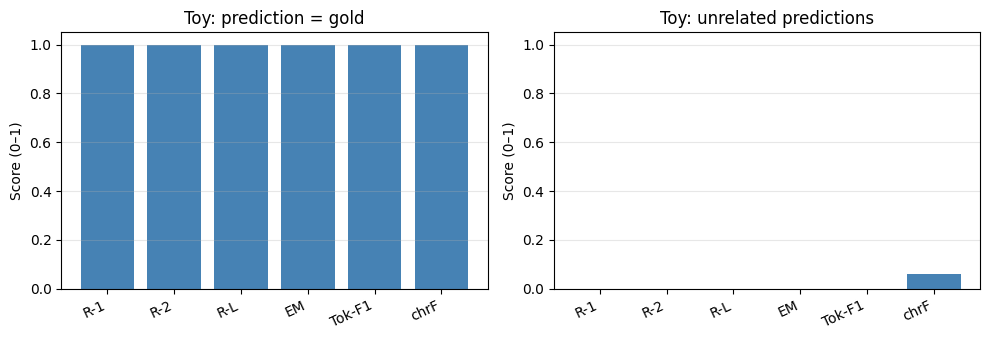

In [16]:
refs_toy = [
    "Summary judgment standard",
    "Discovery sanctions",
]
good_preds = list(refs_toy)
bad_preds = [
    "Weather report",
    "Totally unrelated heading",
]

agg_good = aggregate(good_preds, refs_toy)
agg_bad = aggregate(bad_preds, refs_toy)
print("Good:")
print_aggregate_metrics(agg_good)
print("Bad:")
print_aggregate_metrics(agg_bad)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_summary_bars(axes[0], agg_good, "Toy: prediction = gold")
plot_summary_bars(axes[1], agg_bad, "Toy: unrelated predictions")
plt.tight_layout()
plt.show()

## Dev split — gold vs cheap baseline

- **Gold-as-prediction:** sanity (scores should cluster high).
- **Baseline:** first ~14 tokens of the passage vs gold heading — expect lower overlap and useful spread for histograms.

In [17]:
if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    raise RuntimeError("Set HUGGINGFACE_HUB_TOKEN (or HF_TOKEN) in .env to load dev split.")

DEV_N = 80
dev_ds = materialize_head(load_arg_summ_split_streaming(SPLIT_DEV), DEV_N)
refs = [row[TARGET_COLUMN] for row in dev_ds]
gold_preds = list(refs)
base_preds = [cheap_baseline(row[SOURCE_COLUMN]) for row in dev_ds]

agg_gold = aggregate(gold_preds, refs)
agg_base = aggregate(base_preds, refs)

print("Gold-as-pred:")
print_aggregate_metrics(agg_gold)
print("Cheap baseline:")
print_aggregate_metrics(agg_base)

RANDOM_SAMPLE_K = 5
sources_dev = [row[SOURCE_COLUMN] for row in dev_ds]
print_random_metric_samples(
    base_preds,
    refs,
    agg_base,
    sources=sources_dev,
    k=min(RANDOM_SAMPLE_K, DEV_N),
    seed=42,
    title=f"Dev N={DEV_N}: cheap baseline — random samples",
)

Gold-as-pred:
{'n': 80,
 'rouge1_f': 1.0,
 'rouge2_f': 1.0,
 'rougeL_f': 1.0,
 'exact_match_rate': 1.0,
 'token_f1_macro': 1.0,
 'chrf_corpus': 1.0}
Cheap baseline:
{'n': 80,
 'rouge1_f': 0.2387,
 'rouge2_f': 0.0708,
 'rougeL_f': 0.1955,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.1929,
 'chrf_corpus': 0.2429}

--- Dev N=80: cheap baseline — random samples (5 of 80) ---

[1] idx=14
  passage: The First Amendment has long vouchsafed control 
over religious functions to religious groups  them-
selves.  That  protect s both religious groups' r ight to au-
tonomy and the government's duty not to control reli-
gious functions. Pet'r …
  gold:    The First Amendment protects religious groups' ability to control who performs important religious functions.
  pred:    The First Amendment has long vouchsafed control over religious functions to religious groups them-
  scores:  R1=0.643 R2=0.308 RL=0.429 EM=0 tokF1=0.500 chrF_s=0.553

[2] idx=3
  passage: Federal law illustrates some of the  t

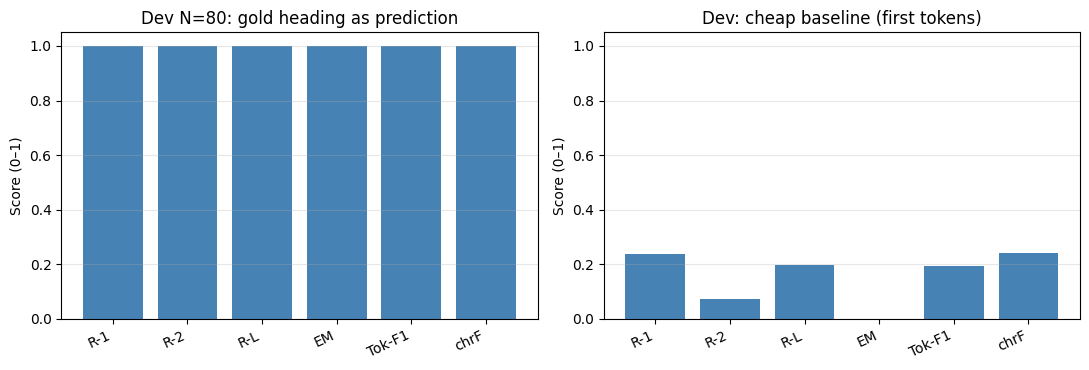

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_summary_bars(axes[0], agg_gold, f"Dev N={DEV_N}: gold heading as prediction")
plot_summary_bars(axes[1], agg_base, "Dev: cheap baseline (first tokens)")
plt.tight_layout()
plt.show()

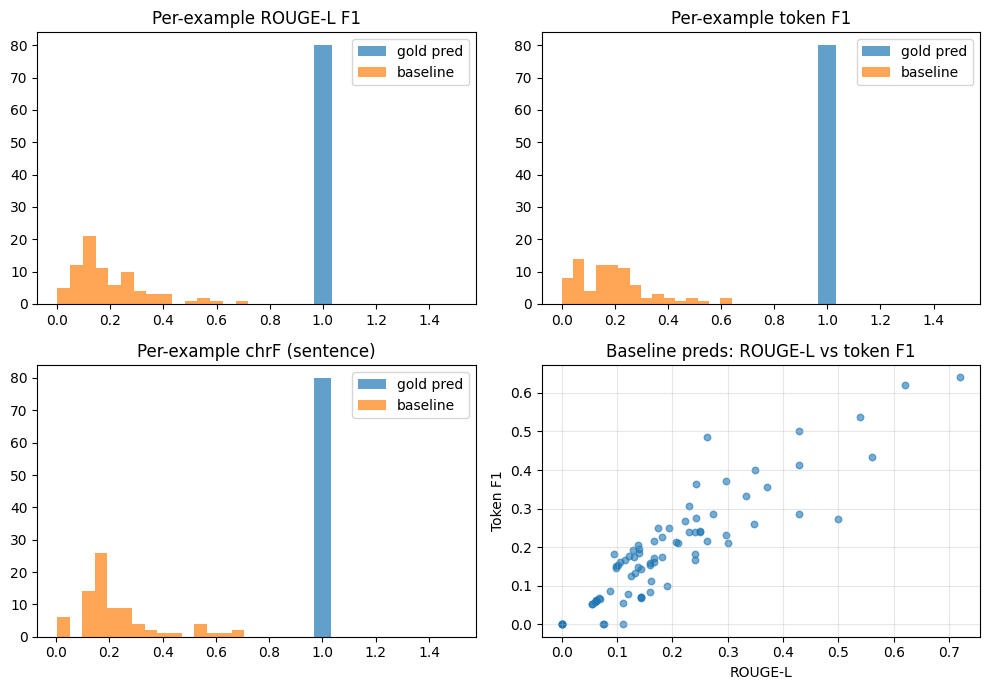

In [19]:
pe_g = agg_gold["per_example"]
pe_b = agg_base["per_example"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(pe_g["rougeL_f"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 0].hist(pe_b["rougeL_f"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 0].set_title("Per-example ROUGE-L F1")
axes[0, 0].legend()

axes[0, 1].hist(pe_g["token_f1"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 1].hist(pe_b["token_f1"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 1].set_title("Per-example token F1")
axes[0, 1].legend()

axes[1, 0].hist(pe_g["chrf"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[1, 0].hist(pe_b["chrf"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[1, 0].set_title("Per-example chrF (sentence)")
axes[1, 0].legend()

ax = axes[1, 1]
ax.scatter(pe_b["rougeL_f"], pe_b["token_f1"], alpha=0.6, s=22)
ax.set_xlabel("ROUGE-L")
ax.set_ylabel("Token F1")
ax.set_title("Baseline preds: ROUGE-L vs token F1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Scratch seq2seq — automated metrics **from saved inference**

**Produce JSON:** **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)** writes `artifacts/inference_runs/{split}_scratch_{tiny|medium}.json` (preds, refs, sources, full `aggregate`). Match **`EVAL_SPLIT`** / **`EVAL_N`** here to those knobs.

This cell **only loads** those files — no checkpoint, no Hub stream, no GPU. LLM-as-judge on the same outputs is **[`02_llm_judge.ipynb`](02_llm_judge.ipynb)**.

Use the **Inference viewer** cell below to browse examples interactively.

In [20]:
from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import load_inference_json, scratch_inference_json_path

# --- match 06_inference_scratch_runs.ipynb ---
EVAL_SPLIT = SPLIT_DEV  # or SPLIT_TEST
EVAL_N = 30
RANDOM_SAMPLE_K = 5

split_tag = "dev" if EVAL_SPLIT == SPLIT_DEV else "test"

for label in ("tiny", "medium"):
    load_path = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=label)
    if not load_path.is_file():
        print(f"[skip] no saved inference at {load_path} — run 06_inference_scratch_runs.ipynb")
        continue
    data = load_inference_json(load_path)
    preds = data["preds"]
    refs = data["refs"]
    sources = data["sources"]
    agg = data["aggregate"]
    print(f"\n=== {split_tag} · scratch {label} ({load_path.relative_to(REPO_ROOT)}) ===")
    print(f"checkpoint (saved): {data['checkpoint']}")
    if data.get("split_tag") != split_tag:
        print(f"[warn] JSON split_tag={data.get('split_tag')} != {split_tag}")
    if int(data.get("eval_n", -1)) != EVAL_N:
        print(f"[warn] JSON eval_n={data.get('eval_n')} != EVAL_N={EVAL_N}")
    print_aggregate_metrics(agg)
    print_random_metric_samples(
        preds,
        refs,
        agg,
        sources=sources,
        k=min(RANDOM_SAMPLE_K, len(preds)),
        seed=42,
        title=f"{split_tag} · scratch {label}",
    )


=== dev · scratch tiny (/Users/naataaniitsosie/repos/cs474/runs/notebook_scratch_tiny_full/best.pt) ===
{'n': 30,
 'rouge1_f': 0.0848,
 'rouge2_f': 0.0,
 'rougeL_f': 0.0698,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.0666,
 'chrf_corpus': 0.1718}

--- dev · scratch tiny (5 of 30) ---

[1] idx=20
  passage: Finally, Respondents argue that lower courts can 
"without treading on First Amendment fre edoms, de-
cide whether [Respondents were] fired for discrimina-
tory reasons." Resp.Br.53 -54. But Hosanna -Tabor  held 
that this "mis ses the p oi…
  gold:    The schools did not need a religious reason.
  pred:    The Ninth Circuit's decision below is not a a a a a a a a a a a a a a a a a a a a a a a a a a a
  scores:  R1=0.140 R2=0.000 RL=0.140 EM=0 tokF1=0.143 chrF_s=0.144

[2] idx=3
  passage: Federal law illustrates some of the  types of regula-
tions that the Second Amendment permit s.  Congress 
has prohibited the possession of firearms by several cat-
egories of people, such as 

## Inference viewer (saved JSON)

Uses files in `artifacts/inference_runs/` produced by **`06_inference_scratch_runs.ipynb`**. Set `VIEW_SPLIT` to match the split you saved (`SPLIT_DEV` vs `SPLIT_TEST`). Re-run **only this cell** to browse examples interactively (requires `ipywidgets`; install with `pip install ipywidgets` if needed).

In [ ]:
from IPython.display import clear_output, display

from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import inference_runs_dir, load_inference_json

VIEW_SPLIT = SPLIT_DEV  # match EVAL_SPLIT from the scratch inference cell
split_tag = "dev" if VIEW_SPLIT == SPLIT_DEV else "test"
RUN_DIR = inference_runs_dir(REPO_ROOT)
paths = sorted(RUN_DIR.glob(f"{split_tag}_scratch_*.json")) if RUN_DIR.is_dir() else []

if not paths:
    print(f"No JSON files in {RUN_DIR} for '{split_tag}_scratch_*.json'. Run the scratch inference cell first.")
else:
    run_options = {p.stem: load_inference_json(p) for p in paths}
    print("Available:", ", ".join(run_options.keys()))

    try:
        import ipywidgets as widgets

        dd = widgets.Dropdown(
            options=list(run_options.keys()),
            description="Run:",
            layout=widgets.Layout(width="min(95%, 560px)"),
        )
        first_n = int(next(iter(run_options.values()))["aggregate"]["n"])
        idx_w = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, first_n - 1),
            step=1,
            description="idx",
        )
        out = widgets.Output()

        def _sync_slider_max(_=None) -> None:
            data = run_options[dd.value]
            n = int(data["aggregate"]["n"])
            idx_w.max = max(0, n - 1)
            if idx_w.value > idx_w.max:
                idx_w.value = idx_w.max

        def _show(_=None) -> None:
            data = run_options[dd.value]
            preds, refs, sources = data["preds"], data["refs"], data["sources"]
            pe = data["aggregate"]["per_example"]
            i = int(idx_w.value)
            with out:
                clear_output(wait=True)
                src = sources[i]
                preview = (src[:2400] + "\n… [truncated]") if len(src) > 2400 else src
                print(f"checkpoint: {data['checkpoint']}")
                print(f"eval_n={data['eval_n']}  label={data['label']}  split={data['split_tag']}\n")
                print(f"[{i}] passage:\n{preview}\n")
                print(f"gold: {refs[i]}\n")
                print(f"pred: {preds[i]}\n")
                print(
                    f"scores: R1={pe['rouge1_f'][i]:.3f} R2={pe['rouge2_f'][i]:.3f} "
                    f"RL={pe['rougeL_f'][i]:.3f} EM={int(pe['exact_match'][i])} "
                    f"tokF1={pe['token_f1'][i]:.3f} chrF_s={pe['chrf'][i]:.3f}"
                )

        def _on_run_change(_=None) -> None:
            _sync_slider_max()
            _show()

        dd.observe(_on_run_change, names="value")
        idx_w.observe(_show, names="value")

        _on_run_change()
        display(dd, idx_w, out)
    except ImportError:
        stem = paths[0].stem
        d0 = run_options[stem]
        print("ipywidgets not installed; showing index 0 of first run only.")
        preds, refs, sources = d0["preds"], d0["refs"], d0["sources"]
        pe = d0["aggregate"]["per_example"]
        i = 0
        print(f"checkpoint: {d0['checkpoint']}\n")
        print(f"[{i}] passage:\n{sources[i][:1200]}…\n")
        print(f"gold: {refs[i]}\npred: {preds[i]}")
        print(
            f"scores: R1={pe['rouge1_f'][i]:.3f} RL={pe['rougeL_f'][i]:.3f} "
            f"tokF1={pe['token_f1'][i]:.3f}"
        )